In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import RMSprop

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

In [3]:
df = pd.read_csv("Churn_Modelling.csv")

print("Shape:", df.shape)
df.info()

Shape: (10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
print(df.isnull().sum())
print(df.duplicated().sum())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
0


In [5]:
df = df.drop_duplicates()

df = df.drop(
    ['RowNumber', 'CustomerId', 'Surname'],
    axis=1
)

df['Geography'] = df['Geography'].str.strip()
df['Gender'] = df['Gender'].str.strip()

print(df['Geography'].unique())
print(df['Gender'].unique())

['France' 'Spain' 'Germany']
['Female' 'Male']


In [6]:
df = pd.get_dummies(
    df,
    columns=['Geography', 'Gender'],
    drop_first=True,
    dtype=int
)

print(df.isnull().sum())
print(df.shape)
df.head()

CreditScore          0
Age                  0
Tenure               0
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
Geography_Germany    0
Geography_Spain      0
Gender_Male          0
dtype: int64
(10000, 12)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [7]:
print(df.describe())

        CreditScore           Age        Tenure        Balance  NumOfProducts  \
count  10000.000000  10000.000000  10000.000000   10000.000000   10000.000000   
mean     650.528800     38.921800      5.012800   76485.889288       1.530200   
std       96.653299     10.487806      2.892174   62397.405202       0.581654   
min      350.000000     18.000000      0.000000       0.000000       1.000000   
25%      584.000000     32.000000      3.000000       0.000000       1.000000   
50%      652.000000     37.000000      5.000000   97198.540000       1.000000   
75%      718.000000     44.000000      7.000000  127644.240000       2.000000   
max      850.000000     92.000000     10.000000  250898.090000       4.000000   

         HasCrCard  IsActiveMember  EstimatedSalary        Exited  \
count  10000.00000    10000.000000     10000.000000  10000.000000   
mean       0.70550        0.515100    100090.239881      0.203700   
std        0.45584        0.499797     57510.492818      0.4027

In [8]:
X = df.drop('Exited', axis=1)
y = df['Exited']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
model = models.Sequential()

model.add(layers.Input(shape=(X_train.shape[1],)))

model.add(layers.Dense(256, activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.5))

model.add(layers.Dense(64, activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.2))

model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dropout(0.1))

model.add(layers.Dense(1, activation='sigmoid'))

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,857 (85.38 KB)

 Trainable params: 21,217 (82.88 KB)

 Non-trainable params: 640 (2.50 KB)

In [13]:
opt = RMSprop(learning_rate=0.001)

model.compile(
    optimizer=opt,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [14]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_delta=1e-4,
    mode='min',
    verbose=1
)

stop_alg = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath='churn_model.keras',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True
)

In [15]:
hist = model.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=50,
    callbacks=[
        stop_alg,
        reduce_lr,
        model_checkpoint
    ],
    shuffle=True,
    validation_split=0.1
)

Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6571 - loss: 0.6460 - val_accuracy: 0.8138 - val_loss: 0.5113 - learning_rate: 0.0010
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8062 - loss: 0.4431 - val_accuracy: 0.8175 - val_loss: 0.4258 - learning_rate: 0.0010
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8276 - loss: 0.4086 - val_accuracy: 0.8225 - val_loss: 0.3917 - learning_rate: 0.0010
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8340 - loss: 0.3929 - val_accuracy: 0.8300 - val_loss: 0.3661 - learning_rate: 0.0010
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8386 - loss: 0.3820 - val_accuracy: 0.8462 - val_loss: 0.3442 - learning_rate: 0.0010
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8446 - loss: 0.3738 - val_accuracy: 0.8650 - val_loss: 0.3269 - learning_rate: 0.0010
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8450 - loss: 0.3771 - val_accuracy

In [16]:
model.save("churn_model.keras")

In [17]:
test_loss, test_acc = model.evaluate(
    X_test,
    y_test,
    verbose=2
)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

63/63 - 0s - 3ms/step - accuracy: 0.8600 - loss: 0.3392
Test Accuracy: 0.8600000143051147
Test Loss: 0.3392307162284851


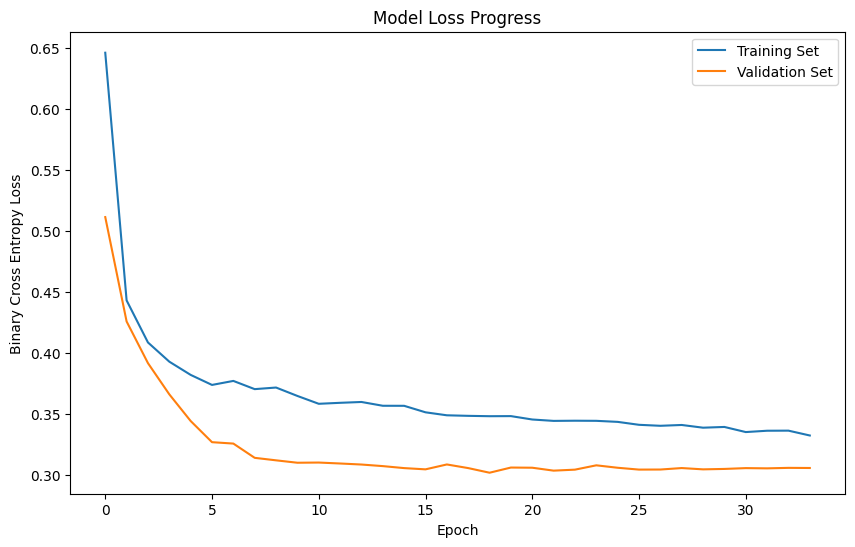

In [18]:
plt.figure(figsize=(10, 6))

plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])

plt.title('Model Loss Progress')
plt.ylabel('Binary Cross Entropy Loss')
plt.xlabel('Epoch')
plt.legend(['Training Set', 'Validation Set'])

plt.show()

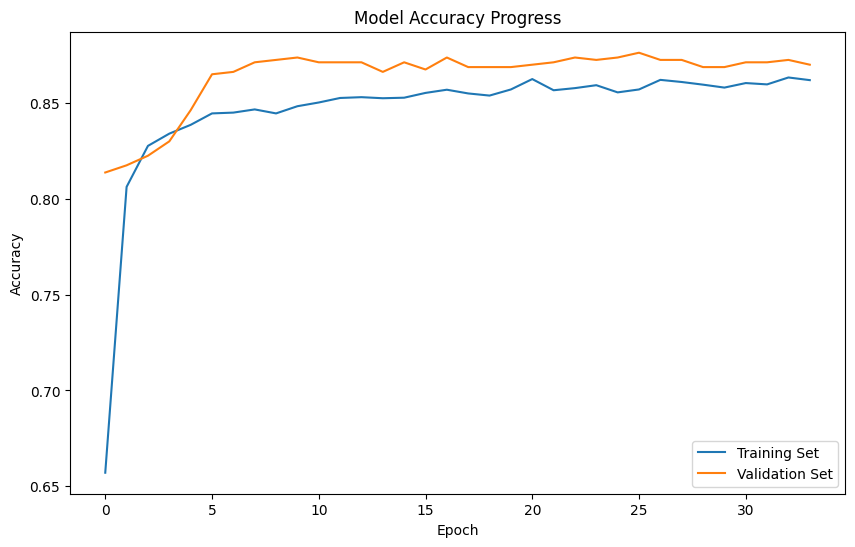

In [19]:
plt.figure(figsize=(10, 6))

plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])

plt.title('Model Accuracy Progress')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training Set', 'Validation Set'])

plt.show()

In [20]:
y_hat = model.predict(X_test)

y_pred = (y_hat >= 0.5).astype(int).ravel()

print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1]
))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.78      0.44      0.56       407

    accuracy                           0.86      2000
   macro avg       0.82      0.70      0.74      2000
weighted avg       0.85      0.86      0.84      2000



In [21]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1]
)

print(cm)

[[1542   51]
 [ 229  178]]


In [22]:
balanced_acc = balanced_accuracy_score(
    y_test,
    y_pred
)

ber = 1 - balanced_acc

print("Balanced Accuracy:", balanced_acc)
print("BER:", ber)

Balanced Accuracy: 0.7026656857165332
BER: 0.2973343142834668


In [23]:
print("True Values:")
print(y_test.values[:20])

print("Predicted Values:")
print(y_pred[:20])

True Values:
[0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0]
Predicted Values:
[0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0]


In [24]:
from tensorflow.keras.models import load_model

model_loaded = load_model("churn_model.keras")

test_loss, test_acc = model_loaded.evaluate(
    X_test,
    y_test,
    verbose=2
)

print("Loaded Model Accuracy:", test_acc)

63/63 - 1s - 8ms/step - accuracy: 0.8600 - loss: 0.3392
Loaded Model Accuracy: 0.8600000143051147
